In [1]:
%matplotlib inline

In [2]:
#Import Libraries here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as scs
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from sktime.transformations.series.outlier_detection import HampelFilter
import os
import sys

In [4]:
current_dir = os.path.abspath('')
project_root = os.path.abspath(os.path.join(current_dir, '../'))

if project_root not in sys.path:
    sys.path.append(project_root)

os.chdir(project_root)

print(f"Working directory set to: {os.getcwd()}")

Working directory set to: D:\users\kamen.dimitrov\desktop\softuni\AI_and_ML_upskill_program\Data Science\08_final_project


In [5]:
#Import project modules here

import importlib
from src.data_pipeline_utils import data_fetching_handling as data_pipe
import src.plotting_utils.plotting_utils as plot_utils
importlib.reload(plot_utils)
importlib.reload(data_pipe)

<module 'src.data_pipeline_utils.data_fetching_handling' from 'D:\\users\\kamen.dimitrov\\desktop\\softuni\\AI_and_ML_upskill_program\\Data Science\\08_final_project\\src\\data_pipeline_utils\\data_fetching_handling.py'>

# Motivation, Background, and Objectives of the Project

This project represents a natural continuation of my prior work in the “Math for Developers” course at SoftUni, where I sought to demonstrate through practical implementation that core mathematical disciplines—linear algebra, calculus, probability theory, statistics, and combinatorics—are not abstract academic constructs, but foundational tools in modern financial science and practice. That earlier effort is available at my GitHub repository: [SoftUni Math for Developers Final Project](https://github.com/Kamend1/math_for_developers_final_project)

In that Math project, I focused primarily on applying the mathematical concepts in price-based modeling and portfolio construction, while in this current work I aim to expand the analytical scope attempting to successfully utilize concepts taught in the Data Science corse at SoftUni toward obtaining relevant data, handling data, time-series analysis, hypothesis testing, and integrating textual data and sentiment as an additional informational layer.

The broader motivation is rooted in the ongoing transformation of financial markets. Quantitative methods are no longer confined to specialized institutions; with the rapid advancement of computing power and the democratization of programming tools such as Python, they are becoming mainstream. Algorithmic investing, once the domain of hedge funds and proprietary trading desks, is now accessible to a much wider audience. High-frequency trading and systematic strategies have already reshaped market microstructure, building upon earlier paradigms such as technical analysis, where practitioners attempted to visually identify patterns in price movements. Today, the frontier extends further into machine learning and natural language processing (NLP), where textual information—earnings announcements, filings, and corporate disclosures—can be transformed into structured signals.

With the availability of pre-trained NLP models such as FinBERT, and the relative ease of deploying them, sentiment analysis has emerged as a promising avenue for extracting potential buy and sell signals. This project seeks to explore whether such sentiment-based signals can provide statistically meaningful insights into short-term price behavior.

From a professional perspective, I approach this topic with both curiosity and skepticism. I have over 20 years of personal and professional experience in capital markets. I am a certified independent appraiser of real estate, financial assets, and financial institutions, a member of the CFA Institute since 2009, and a licensed investment consultant from the Bulgarian Financial Supervision Commission. Throughout my career, I have adhered to the principle that intrinsic value is derived from the fundamental characteristics of an asset, and that past price performance is not a reliable predictor of future valuation. Consequently, I have traditionally placed limited weight on purely statistical or sentiment-based forecasting approaches.

However, I am also deeply interested in technology and continuous learning. Since 2023, I have been actively developing my programming skills in Python through SoftUni, accumulating approximately 150 credits and participating in the AI and ML upskill program. My first exposure to practical applications of artificial neural networks dates back to 2005, during my time as a credit analyst and junior portfolio manager at Voyageur Asset Management in Minneapolis (now part of RBC Asset Management (US) Inc.). At that time, we utilized a licensed ANN-based system to assess credit risk in high-yield corporate bond issuers. This early experience sparked a long-standing interest in quantitative modeling and machine learning, well before the emergence of modern large language models.

In my current role as an executive in a manufacturing company, I emphasize a data-driven approach to decision-making. I actively seek to reduce cognitive biases and adapt strategies based on evolving data and conditions. This project is an extension of that mindset. I aim to construct a framework that integrates multiple data sources: historical price data from Yahoo Finance via the yfinance API, financial disclosures from the SEC EDGAR database, and textual data from corporate filings such as 8-K reports and 10-Q Management Discussion & Analysis sections. Through feature engineering on price data and sentiment extraction from textual data, I intend to define and test trading signals.

The primary objective is to determine whether these signals exhibit statistically significant relationships with subsequent stock price movements. The project will focus on a universe of 30 large-cap stocks across different sectors. I will use a 10-year dataset, dividing it into two periods: the first five years for portfolio optimization (including efficient frontier construction and weight determination), and the second five years for time-series analysis and signal testing. The trading framework will simulate a long-only strategy, where positions are initiated upon buy signals and closed upon sell signals, subject to constraints such as maximum position size and transaction costs.

A parallel objective is to evaluate sentiment-driven signals. Using the FinBERT model, I will analyze textual disclosures and test whether sentiment scores have predictive power over short-term horizons (2, 3, 5, and 10 days).

**A significant setback** during the initial phase of the project was related to data sourcing. I initially intended to use earnings call transcripts, which are publicly discussed but not freely distributed. Available datasets, such as those on Kaggle (including the Motley Fool dataset), appear to have been compiled through scraping in violation of terms and conditions. Similar concerns apply to datasets on other platforms, likely sourced from providers such as Seeking Alpha or Financial Modeling Prep. Given these **legal and ethical considerations**, I decided to abandon this approach despite having already invested substantial time in it. Instead, I pivoted to using officially available filings, acknowledging that these may contain management bias and may not yield strong statistical results.

This project is driven entirely by personal curiosity. I approach it with an open and unbiased mindset, fully prepared for the possibility that the hypotheses may not hold. I will use various coding resources and may seek assistance from language models where appropriate, but the conceptual framework, data selection, feature engineering, and hypothesis testing are my own. The results—whether successful or not—will reflect my own reasoning, including any methodological limitations.

The project will be published on my GitHub repository under an MIT license. It is important to emphasize that this work does not constitute investment advice or a recommendation. Rather, it is an exploratory exercise at the intersection of finance, data science, and machine learning.

Let us proceed with the analysis.

The first stage builds a clean financial dataset and explores the statistical properties of returns, including volatility, outliers, distribution shape, and persistence. Later stages test whether these features can be converted into predictive signals for subsequent returns.

# 1. Prepare data using the pipeline

In [7]:
tickers = [
    "AAPL", "GOOG", "MSFT", "NVDA",
    "JPM", "BAC", "F", "UPS", "WMT", "TGT",
    "VZ", "T", "FE", "PFE", "JNJ", "DIS",
    "V", "MCD", "NKE", "XOM", "CVX",
    "CAT", "DE", "LMT", "AMD", "INTC", "ORCL", 
    "CRM", "CB", "PG"
]

all_df_shapes = {}

for ticker in tickers:
    data = data_pipe.save_10_year_single_stock_data_to_csv(ticker)
    return_data = data_pipe.create_returns_and_save(data, ticker)
    all_df_shapes[ticker] = return_data.shape

all_same = set(all_df_shapes.values())
print(f"{len(all_same)} - a result of 1 is a green light to go as all datasets are complete, if not go back and choose different stocks.")

1 - a result of 1 is a green light to go as all datasets are complete, if not go back and choose different stocks.


In [11]:
AAPL_data = data_pipe.fetch_raw_data('AAPL')
return_data = data_pipe.fetch_returns_data('ACM')

return_data

,Close,High,Low,Open,Volume,daily_return,log_return,daily_return_pct,log_return_pct
Date,,,,,,,,,
2016-03-29,30.043335,30.062569,29.081640,29.225894,889300,0.022921,0.022662,2.292073,2.266200
2016-03-30,29.783678,30.293377,29.639424,30.293377,477400,-0.008643,-0.008680,-0.864275,-0.868031
2016-03-31,29.610571,29.822143,29.504784,29.822143,685600,-0.005812,-0.005829,-0.581215,-0.582910
2016-04-01,29.629807,29.764445,29.120110,29.187428,626700,0.000650,0.000649,0.064962,0.064941
2016-04-04,29.302832,29.687511,29.245130,29.658659,444100,-0.011035,-0.011097,-1.103534,-1.109668
...,...,...,...,...,...,...,...,...,...
2026-03-23,90.059998,92.000000,89.470001,90.320000,1263800,0.016708,0.016570,1.670801,1.656997
2026-03-24,88.849998,89.699997,88.320000,89.070000,1047400,-0.013435,-0.013527,-1.343548,-1.352655
2026-03-25,88.540001,90.900002,87.459999,90.000000,787400,-0.003489,-0.003495,-0.348900,-0.349510


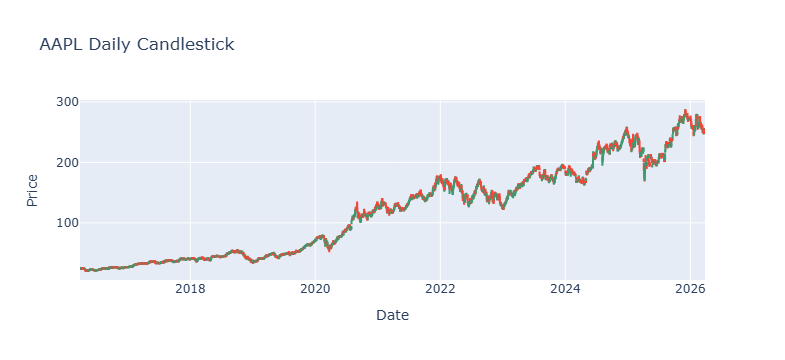

In [13]:
fig = plot_utils.create_candlestick_graph('AAPL')
fig.show()

# 2. Here we deviate from the previous project. Let's do some time series data exploration
Let's work with the returns dataframe created above

-  the rolling method in Pandas with parameters:
-  window = 21, we choose this for 21 trading days on average in a month
-  min_periods = 1, for the first 20 rows it gradually expands until it reaches 21
-  dropna(), because on the earliest day (first row), column 'std' remains NaN

In [14]:
stats = return_data['log_return'].rolling(window=21, min_periods=1).agg(['mean', 'std'])
return_data = pd.concat([return_data, stats], axis=1)

return_data

,Close,High,Low,Open,Volume,daily_return,log_return,daily_return_pct,log_return_pct,mean,std
Date,,,,,,,,,,,
2016-03-29,30.043335,30.062569,29.081640,29.225894,889300,0.022921,0.022662,2.292073,2.266200,0.022662,NaN
2016-03-30,29.783678,30.293377,29.639424,30.293377,477400,-0.008643,-0.008680,-0.864275,-0.868031,0.006991,0.022162
2016-03-31,29.610571,29.822143,29.504784,29.822143,685600,-0.005812,-0.005829,-0.581215,-0.582910,0.002718,0.017331
2016-04-01,29.629807,29.764445,29.120110,29.187428,626700,0.000650,0.000649,0.064962,0.064941,0.002200,0.014189
2016-04-04,29.302832,29.687511,29.245130,29.658659,444100,-0.011035,-0.011097,-1.103534,-1.109668,-0.000459,0.013651
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-23,90.059998,92.000000,89.470001,90.320000,1263800,0.016708,0.016570,1.670801,1.656997,-0.003970,0.021772
2026-03-24,88.849998,89.699997,88.320000,89.070000,1047400,-0.013435,-0.013527,-1.343548,-1.352655,-0.002317,0.019435
2026-03-25,88.540001,90.900002,87.459999,90.000000,787400,-0.003489,-0.003495,-0.348900,-0.349510,-0.003524,0.018630


In [16]:
#TODO Create a method

N_SIGMAS = 3

return_data["upper"] = return_data["mean"] + N_SIGMAS * return_data["std"]
return_data["lower"] = return_data["mean"] - N_SIGMAS * return_data["std"]

return_data["outlier"] = (
    (return_data["log_return"] > return_data["upper"]) | 
    (return_data["log_return"] < return_data["lower"])
)

return_data = return_data.dropna()
return_data

,Close,High,Low,Open,Volume,daily_return,log_return,daily_return_pct,log_return_pct,mean,std,upper,lower,outlier
Date,,,,,,,,,,,,,,
2016-03-30,29.783678,30.293377,29.639424,30.293377,477400,-0.008643,-0.008680,-0.864275,-0.868031,0.006991,0.022162,0.073478,-0.059496,False
2016-03-31,29.610571,29.822143,29.504784,29.822143,685600,-0.005812,-0.005829,-0.581215,-0.582910,0.002718,0.017331,0.054711,-0.049276,False
2016-04-01,29.629807,29.764445,29.120110,29.187428,626700,0.000650,0.000649,0.064962,0.064941,0.002200,0.014189,0.044766,-0.040365,False
2016-04-04,29.302832,29.687511,29.245130,29.658659,444100,-0.011035,-0.011097,-1.103534,-1.109668,-0.000459,0.013651,0.040494,-0.041412,False
2016-04-05,28.562326,29.158576,28.543092,29.023939,607000,-0.025271,-0.025596,-2.527077,-2.559556,-0.004648,0.015950,0.043200,-0.052497,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-23,90.059998,92.000000,89.470001,90.320000,1263800,0.016708,0.016570,1.670801,1.656997,-0.003970,0.021772,0.061346,-0.069285,False
2026-03-24,88.849998,89.699997,88.320000,89.070000,1047400,-0.013435,-0.013527,-1.343548,-1.352655,-0.002317,0.019435,0.055988,-0.060622,False
2026-03-25,88.540001,90.900002,87.459999,90.000000,787400,-0.003489,-0.003495,-0.348900,-0.349510,-0.003524,0.018630,0.052367,-0.059414,False


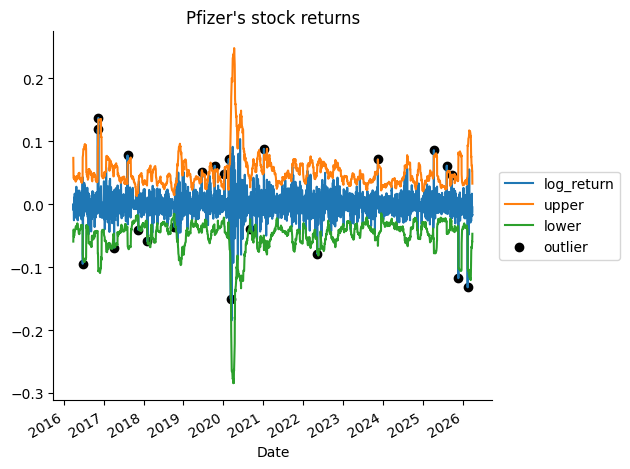

In [19]:
#TODO Create a plot util method

fig, ax = plt.subplots()

return_data[["log_return", "upper", "lower"]].plot(ax=ax)
ax.scatter(return_data.loc[return_data["outlier"]].index, 
           return_data.loc[return_data["outlier"], "log_return"], 
           color="black", label="outlier")
ax.set_title("Aecom's stock returns")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

sns.despine()
plt.tight_layout()

C:\Users\kamen.dimitrov\AppData\Local\Temp\ipykernel_7648\3422101570.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



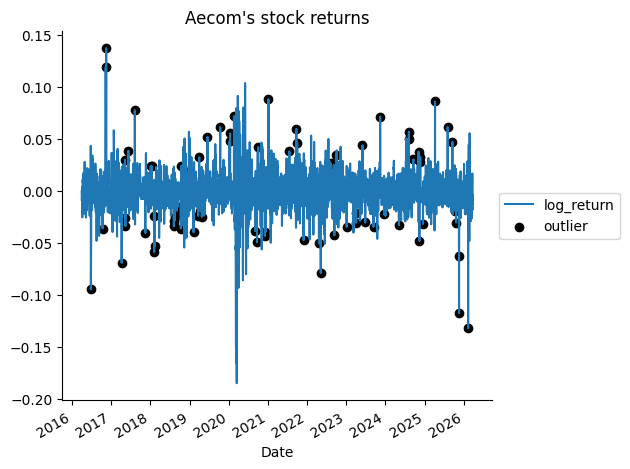

In [20]:
hampel_detector = HampelFilter(window_length=21, return_bool=True)
return_data["outlier_rtn"] = hampel_detector.fit_transform(return_data["log_return"])

fig, ax = plt.subplots()

return_data[["log_return"]].plot(ax=ax)
ax.scatter(return_data.loc[return_data["outlier_rtn"]].index, 
           return_data.loc[return_data["outlier_rtn"], "log_return"], 
           color="black", label="outlier")
ax.set_title("Aecom's stock returns")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

sns.despine()
plt.tight_layout()

The Hurst Exponent ($H$) is a statistical measure used to classify time series data based on its "memory." In the context of your Python for Finance Cookbook, it is the primary tool for determining if a stock's price is trending, mean-reverting, or just a random walk.Mathematically, it relates to the autocorrelations of the time series and the rate at which the variance of the series increases over time.1. The Three Regimes of $H$The value of $H$ always falls between 0 and 1. Where it lands tells you the "nature" of the asset:Value of HRegimeMarket Behavior$H < 0.5$Mean-Reverting"Anti-persistent." If the price goes up, it is likely to go back down soon. Great for "Pairs Trading."$H = 0.5$Random WalkGeometric Brownian Motion. Past movement has zero influence on future movement (Efficient Market Hypothesis).$H > 0.5$Trending"Persistent." If the price is moving up, it is likely to keep moving up. Ideal for "Momentum Trading."

In [21]:
#TODO Export method in time series analysis
def get_hurst_exponent(ts, lag):
    """Returns the Hurst Exponent of a time series"""
    lags = range(2, lag)
    # Calculate the variance of the differenced series
    tau = [np.sqrt(np.std(np.subtract(ts[lag:], ts[:-lag]))) for lag in lags]
    # Use a linear fit to estimate the Hurst Exponent
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0] * 2.0

In [23]:
for lag in [20, 100, 250, 500, 1000]:
    hurst_exp = get_hurst_exponent(return_data["Close"].values, lag)
    print(f"Hurst exponent with {lag} lags: {hurst_exp:.4f}")


Hurst exponent with 20 lags: 0.4975
Hurst exponent with 100 lags: 0.4802
Hurst exponent with 250 lags: 0.2830
Hurst exponent with 500 lags: 0.2663
Hurst exponent with 1000 lags: 0.2895


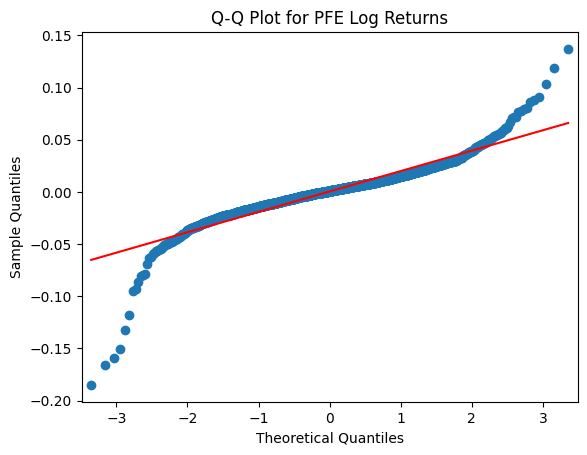

In [25]:
#TODO method in plot utils and explain further
fig = sm.qqplot(return_data['log_return'].dropna(), line='s')
plt.title("Q-Q Plot for ACM Log Returns")
plt.show()

Mean log return in observation period: 0.0004158343601541424,
Variance of log returns in observation period: 0.00038236987587227995,
Standard deviation of log returns in observation period: 0.01955428024429127


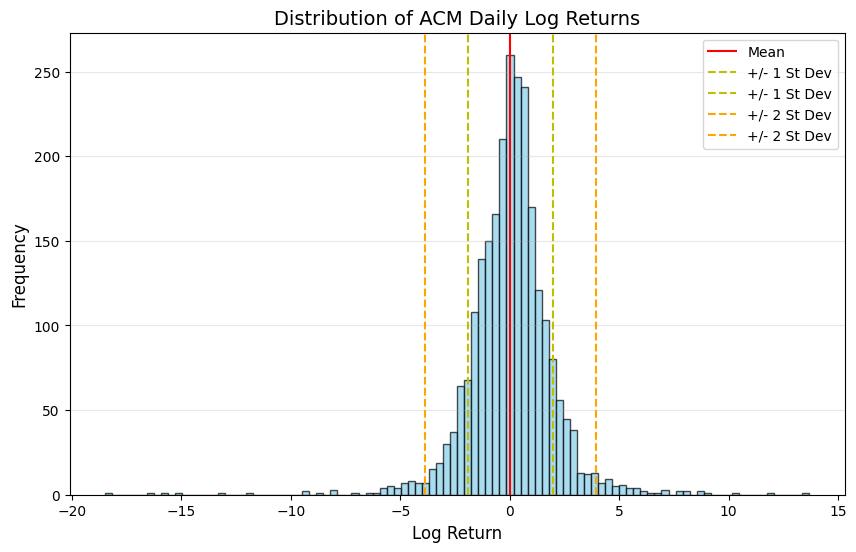

In [26]:
mean = return_data["log_return"].mean()
variance = return_data["log_return"].var()
st_dev = return_data["log_return"].std()

print(f"Mean log return in observation period: {mean},\n"
      f"Variance of log returns in observation period: {variance},\n"
      f"Standard deviation of log returns in observation period: {st_dev}")

ticker = 'ACM'
fig = plot_utils.create_histogram_distribution_daily_log_returns(return_data, ticker, mean, st_dev)
plt.show()

In [28]:
jb_test = scs.jarque_bera(return_data["log_return"].values)

print("---------- Descriptive Statistics ----------")
print("Range of dates:", min(return_data.index.date), "-", max(return_data.index.date))
print("Number of observations:", return_data.shape[0])
print(f"Mean: {return_data.log_return.mean():.4f}")
print(f"Median: {return_data.log_return.median():.4f}")
print(f"Min: {return_data.log_return.min():.4f}")
print(f"Max: {return_data.log_return.max():.4f}")
print(f"Standard Deviation: {return_data.log_return.std():.4f}")
print(f"Skewness: {return_data.log_return.skew():.4f}")
print(f"Kurtosis: {return_data.log_return.kurtosis():.4f}") 
print(f"Jarque-Bera statistic: {jb_test[0]:.2f} with p-value: {jb_test[1]:.2f}")

---------- Descriptive Statistics ----------
Range of dates: 2016-03-30 - 2026-03-27
Number of observations: 2514
Mean: 0.0004
Median: 0.0009
Min: -0.1850
Max: 0.1370
Standard Deviation: 0.0196
Skewness: -0.8503
Kurtosis: 12.8696
Jarque-Bera statistic: 17576.70 with p-value: 0.00


#TODO Conclusions

In [ ]:
#TODO Autocorrelation

In [ ]:
#TODO volatility clustering